<a href="https://colab.research.google.com/github/sathwikayasa/student-retention-early-warning/blob/main/01_explore_and_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo -q
import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print(df.shape)
df.head()

(4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
import re
df.columns = [re.sub(r'[^0-9a-z]+', '_', c.lower()).strip('_') for c in df.columns]

if 'student_id' not in df.columns:
    df.insert(0, 'student_id', range(1, len(df) + 1))

print(list(df.columns))
print(df.isna().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicate rows")

['student_id', 'marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']
0 missing values
0 duplic

          students  percent
target                     
Graduate      2209     49.9
Dropout       1421     32.1
Enrolled       794     17.9


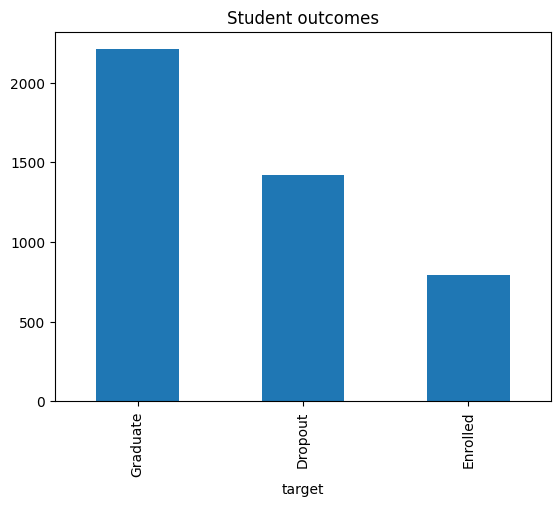

In [5]:
counts = df['target'].value_counts()
pct = (df['target'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({'students': counts, 'percent': pct}))
counts.plot(kind='bar', title='Student outcomes');

In [6]:
course_names = {33:'Biofuel Production Technologies', 171:'Animation and Multimedia Design',
 8014:'Social Service (evening)', 9003:'Agronomy', 9070:'Communication Design',
 9085:'Veterinary Nursing', 9119:'Informatics Engineering', 9130:'Equinculture',
 9147:'Management', 9238:'Social Service', 9254:'Tourism', 9500:'Nursing',
 9556:'Oral Hygiene', 9670:'Advertising and Marketing Management',
 9773:'Journalism and Communication', 9853:'Basic Education', 9991:'Management (evening)'}
df['course_name'] = df['course'].map(course_names)
print(df['course_name'].isna().sum(), "unmapped courses")

yes_no = {1: 'Yes', 0: 'No'}
for col in ['debtor', 'tuition_fees_up_to_date', 'scholarship_holder']:
    df[col + '_label'] = df[col].map(yes_no)
df['gender_label'] = df['gender'].map({1: 'Male', 0: 'Female'})

df['is_dropout'] = (df['target'] == 'Dropout').astype(int)
df['sem1_pass_rate'] = (df['curricular_units_1st_sem_approved'] /
                        df['curricular_units_1st_sem_enrolled']).where(
                        df['curricular_units_1st_sem_enrolled'] > 0)

0 unmapped courses


                                      students  dropout_rate
course_name                                                 
Biofuel Production Technologies             12          66.7
Equinculture                               141          55.3
Informatics Engineering                    170          54.1
Management (evening)                       268          50.7
Basic Education                            192          44.3
Agronomy                                   210          41.0
Oral Hygiene                                86          38.4
Animation and Multimedia Design            215          38.1
Tourism                                    252          38.1
Advertising and Marketing Management       268          35.4
Management                                 380          35.3
Social Service (evening)                   215          33.0
Journalism and Communication               331          30.5
Veterinary Nursing                         337          26.7
Communication Design    

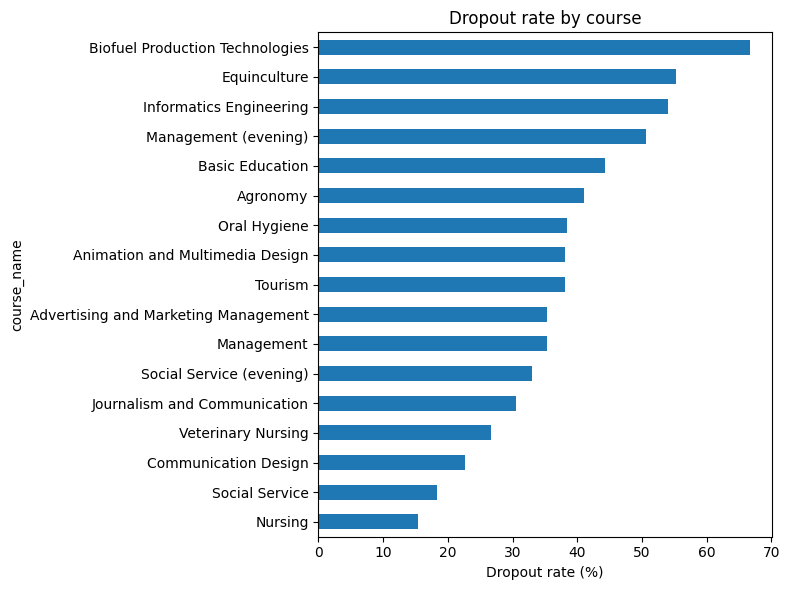

In [7]:
by_course = (df.groupby('course_name')['is_dropout']
               .agg(students='count', dropout_rate='mean')
               .sort_values('dropout_rate', ascending=False))
by_course['dropout_rate'] = (by_course['dropout_rate'] * 100).round(1)
print(by_course)

for col in ['tuition_fees_up_to_date_label', 'scholarship_holder_label', 'debtor_label']:
    print((df.groupby(col)['is_dropout'].mean() * 100).round(1), '\n')

print(df.groupby('target')['sem1_pass_rate'].mean().round(2))

import matplotlib.pyplot as plt
by_course['dropout_rate'].sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('Dropout rate (%)'); plt.title('Dropout rate by course')
plt.tight_layout(); plt.show()

In [8]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('students', conn, index=False, if_exists='replace')

q1 = """
SELECT course_name,
       COUNT(*) AS students,
       ROUND(100.0 * SUM(CASE WHEN target = 'Dropout' THEN 1 ELSE 0 END) / COUNT(*), 1) AS dropout_rate_pct
FROM students
GROUP BY course_name
ORDER BY dropout_rate_pct DESC;
"""
print(pd.read_sql(q1, conn))

q2 = """
SELECT tuition_fees_up_to_date_label AS tuition_current,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(is_dropout), 1) AS dropout_rate_pct
FROM students
GROUP BY tuition_fees_up_to_date_label;
"""
print(pd.read_sql(q2, conn))

                             course_name  students  dropout_rate_pct
0        Biofuel Production Technologies        12              66.7
1                           Equinculture       141              55.3
2                Informatics Engineering       170              54.1
3                   Management (evening)       268              50.7
4                        Basic Education       192              44.3
5                               Agronomy       210              41.0
6                           Oral Hygiene        86              38.4
7                                Tourism       252              38.1
8        Animation and Multimedia Design       215              38.1
9   Advertising and Marketing Management       268              35.4
10                            Management       380              35.3
11              Social Service (evening)       215              33.0
12          Journalism and Communication       331              30.5
13                    Veterinary N

In [9]:
q3 = """
SELECT scholarship_holder_label AS scholarship,
       COUNT(*) AS students,
       ROUND(100.0 * AVG(is_dropout), 1) AS dropout_rate_pct
FROM students
GROUP BY scholarship_holder_label;
"""
print(pd.read_sql(q3, conn))

  scholarship  students  dropout_rate_pct
0          No      3325              38.7
1         Yes      1099              12.2


In [11]:
sql_text = """-- Dropout rate by course
""" + q1 + """

-- Dropout rate by tuition status
""" + q2 + """

-- Dropout rate by scholarship status
""" + q3

with open('kpi_queries.sql', 'w') as f:
    f.write(sql_text)

from google.colab import files
files.download('kpi_queries.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
df.to_csv('students_clean.csv', index=False)
from google.colab import files
files.download('students_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
df[['unemployment_rate','inflation_rate','gdp','age_at_enrollment']].describe()

,unemployment_rate,inflation_rate,gdp,age_at_enrollment
count,4424.000000,4424.000000,4424.000000,4424.000000
mean,11.566139,1.228029,0.001969,23.265145
std,2.663850,1.382711,2.269935,7.587816
min,7.600000,-0.800000,-4.060000,17.000000
25%,9.400000,0.300000,-1.700000,19.000000
50%,11.100000,1.400000,0.320000,20.000000
75%,13.900000,2.600000,1.790000,25.000000
max,16.200000,3.700000,3.510000,70.000000


In [16]:
feature_cols = [
    'marital_status', 'application_mode', 'application_order', 'course',
    'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade',
    'mother_s_qualification', 'father_s_qualification', 'mother_s_occupation', 'father_s_occupation',
    'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
    'tuition_fees_up_to_date', 'scholarship_holder', 'age_at_enrollment',
    'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled',
    'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved',
    'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations',
    'unemployment_rate', 'inflation_rate', 'gdp'
]

X = df[feature_cols]
y = df['is_dropout']

print(X.shape, y.shape)
print(y.value_counts())

(4424, 27) (4424,)
is_dropout
0    3003
1    1421
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(3539, 27) (885, 27)
is_dropout
0    0.679
1    0.321
Name: proportion, dtype: float64
is_dropout
0    0.679
1    0.321
Name: proportion, dtype: float64


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

log_reg = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

log_reg.fit(X_train, y_train)
print("Trained.")

Trained.


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not dropout', 'Dropout']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

 Not dropout       0.90      0.88      0.89       601
     Dropout       0.76      0.79      0.77       284

    accuracy                           0.85       885
   macro avg       0.83      0.84      0.83       885
weighted avg       0.85      0.85      0.85       885

ROC-AUC: 0.903
[[528  73]
 [ 59 225]]


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10,
                                      class_weight='balanced', random_state=42))
])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Not dropout', 'Dropout']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

 Not dropout       0.88      0.91      0.90       601
     Dropout       0.80      0.73      0.76       284

    accuracy                           0.86       885
   macro avg       0.84      0.82      0.83       885
weighted avg       0.85      0.86      0.85       885

ROC-AUC: 0.901
[[549  52]
 [ 76 208]]


In [21]:
import numpy as np

coefs = log_reg.named_steps['model'].coef_[0]
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': coefs
}).sort_values('coefficient', key=abs, ascending=False)

print(feature_importance.head(10))

                              feature  coefficient
21  curricular_units_1st_sem_approved    -2.314044
19  curricular_units_1st_sem_enrolled     0.744785
15            tuition_fees_up_to_date    -0.739784
18  curricular_units_1st_sem_credited     0.734346
17                  age_at_enrollment     0.403690
9                 mother_s_occupation    -0.383860
3                              course     0.328655
16                 scholarship_holder    -0.279998
14                             debtor     0.238703
24                  unemployment_rate     0.174916


In [22]:
df['dropout_risk_score'] = log_reg.predict_proba(X)[:, 1]
df['risk_tier'] = pd.cut(df['dropout_risk_score'], bins=[0, 0.3, 0.6, 1.0],
                          labels=['Low', 'Medium', 'High'])

print(df[['student_id', 'dropout_risk_score', 'risk_tier', 'target']].head(10))
print(df['risk_tier'].value_counts())

   student_id  dropout_risk_score risk_tier    target
0           1            0.581042    Medium   Dropout
1           2            0.711079      High  Graduate
2           3            0.996865      High   Dropout
3           4            0.170006       Low  Graduate
4           5            0.372733    Medium  Graduate
5           6            0.662625      High  Graduate
6           7            0.064294       Low  Graduate
7           8            0.997054      High   Dropout
8           9            0.096555       Low  Graduate
9          10            0.866559      High   Dropout
risk_tier
Low       2320
High      1265
Medium     839
Name: count, dtype: int64


In [23]:
df.to_csv('students_scored.csv', index=False)
from google.colab import files
files.download('students_scored.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>